In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import re
import stan
import seaborn as sns
import scipy.special
from pathlib import Path
from datetime import datetime

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load territory data
terr = pd.read_csv('processed_data/territory_data.csv')
ndvi = pd.read_csv('rawdata/Velavadar/ndvi.csv')

## Parse dates
terr['date'] = pd.to_datetime(terr['Date'], format='%Y-%b')
ndvi['date'] = pd.to_datetime(ndvi['Label'])

## Pivot to wide so we have one row per timepoint
## Get territory counts on each lek
df = (terr.pivot_table(index='date', columns='Lek', values='count', aggfunc='sum').sort_index()
        .rename(columns={1: 'N1', 2: 'N2'}).rename_axis(None, axis=1).reset_index().sort_values('date'))


## Add columns for the total number of territories and the proportion of territories on site 1 and site 2
df['logN1'] = np.log(df['N1'])
df['logN2'] = np.log(df['N2'])
df['N'] = df['N1'] + df['N2']
df['p1'] = df['N1']/df['N']
df['p2'] = df['N2']/df['N']


## Merge NDVI information into this dataframe
df = df.merge(ndvi, on='date', how='left').drop(columns=['Label']).rename(columns={'Polygon 1': 'NDVI1', 'Polygon 2': 'NDVI2'})
df['dNDVI'] = df['NDVI2'] - df['NDVI1']
df.head()

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,date,N1,N2,logN1,logN2,N,p1,p2,NDVI1,NDVI2,dNDVI
0,2013-12-01,43,0,3.761200,-inf,43,1.000000,0.000000,0.307,0.315,0.008
1,2014-02-01,73,25,4.290459,3.218876,98,0.744898,0.255102,0.227,0.238,0.011
2,2014-10-01,37,1,3.610918,0.000000,38,0.973684,0.026316,0.371,0.386,0.015
3,2015-05-01,83,76,4.418841,4.330733,159,0.522013,0.477987,0.173,0.170,-0.003
4,2015-11-01,49,19,3.891820,2.944439,68,0.720588,0.279412,0.279,0.295,0.016


In [4]:
## Colour palettes
fill_cols = {'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

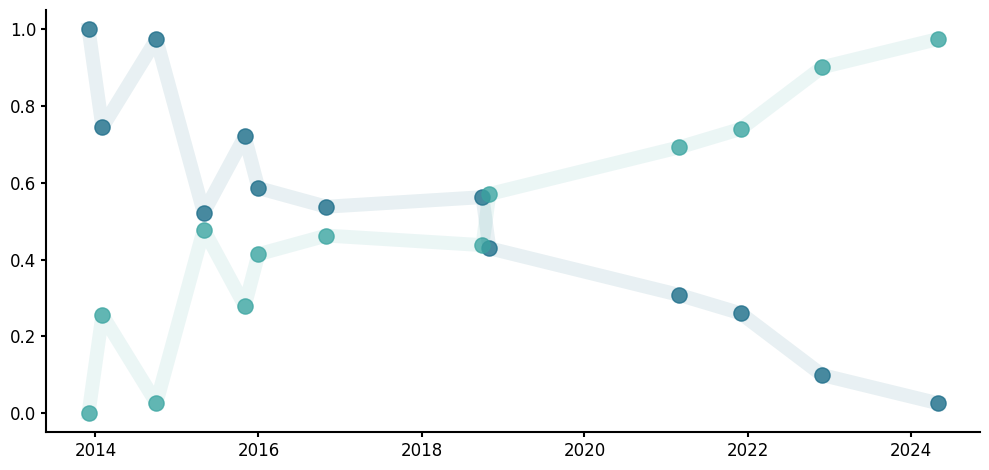

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.8))

## Plot the two sites over time
ax.scatter(df['date'], df['p1'], s=120, color=fill_cols.get('Velavadar Lek 1'), edgecolor=fill_cols.get('Velavadar Lek 1'), alpha=0.8)
ax.scatter(df['date'], df['p2'], s=120, color=fill_cols.get('Velavadar Lek 2'), edgecolor=fill_cols.get('Velavadar Lek 2'), alpha=0.8)
ax.plot(df['date'], df['p1'], color=fill_cols['Velavadar Lek 1'], linewidth=10, alpha=0.1)
ax.plot(df['date'], df['p2'], color=fill_cols['Velavadar Lek 2'], linewidth=10, alpha=0.1)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.set_ylabel('', fontsize=14)
ax.set_xlabel('', fontsize=14)

ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.margins(x=0.05)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='both', labelsize=12, width=1.5)

plt.tight_layout()
plt.savefig(out_dir/'transition_data.png', dpi=300)

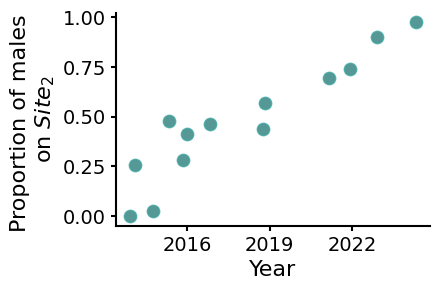

In [6]:
## Plot the transition of males from site 1 to site 2
fig, ax = plt.subplots(figsize=(4.5, 3))

## Add observed data as scatter
ax.scatter(df['date'], df['p2'], s=80, color=point_cols.get('Velavadar Lek 2'), edgecolor=fill_cols.get('Velavadar Lek 2'), alpha=0.8, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=14, width=1.5)

ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Proportion of males \non $Site_{2}$', fontsize=16)
ax.xaxis.set_major_locator(mdates.YearLocator(3))

plt.tight_layout()
plt.savefig(out_dir/'transition_single_data.png', dpi=300)

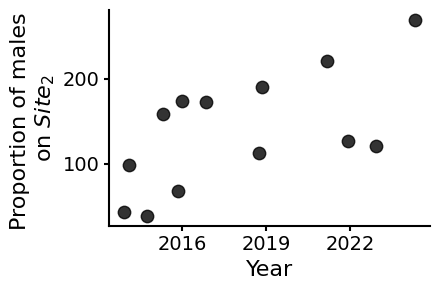

In [7]:
## Plot the transition of males from site 1 to site 2
fig, ax = plt.subplots(figsize=(4.5, 3))

## Add observed data as scatter
ax.scatter(df['date'], df['N'], s=80, color='black', edgecolor='black', alpha=0.8, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=14, width=1.5)

ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Proportion of males \non $Site_{2}$', fontsize=16)
ax.xaxis.set_major_locator(mdates.YearLocator(3))

plt.tight_layout()

### Descriptive plots

In [8]:
df['date'] = pd.to_datetime(df['date'])

df_desc = df[['date', 'N', 'dNDVI']].dropna().copy()
df_desc = df_desc.sort_values(['date']).reset_index(drop=True)

## Serialise and centre the date / time
t0 = df_desc['date'].min()
df_desc['t_years'] = (df_desc['date'] - t0).dt.days / 365.25
df_desc['t_centred'] = df_desc['t_years'] - df_desc['t_years'].mean()

In [9]:
## Specify time axis
t_min, t_max = float(df_desc['t_centred'].min()), float(df_desc['t_centred'].max())
t_grid = np.linspace(t_min, t_max, 200)
t_years = t_grid + df_desc['t_years'].mean()
date_grid = t0 + pd.to_timedelta(t_years * 365.25, unit='D')

In [10]:
## 1) Total number of territories through time
nnd_mod = """
data {
  int<lower=1> n_points;

  vector[n_points] t;
  array[n_points] int<lower=0> y;
}

parameters {
  real alpha;
  real beta;

  real<lower=0> phi;
}

transformed parameters {
  vector[n_points] mu;

  for (n in 1:n_points) {
    mu[n] = exp(alpha + beta * t[n]);  // log-link for counts
  }
}

model {
  alpha ~ normal(0, 1);
  beta ~ normal(0, 1);
  phi ~ exponential(1);

  y ~ neg_binomial_2(mu, phi);
}
"""

In [11]:
nnd_data = {
    'n_points': len(df),
    't': df_desc['t_centred'].astype(float).to_numpy(),
    'y': df_desc['N'].astype(int).to_numpy()
}

posterior = stan.build(nnd_mod, data=nnd_data)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 4.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.42 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: neg_binomial_2_lpmf: Location parameter[1] is 0, but must be positive finite! (in '/tmp/httpstan_x4gl98vb/model_thivhepb.stan', line 29, column 2 to column 30)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Informational Message: The current Metropolis proposal is about to be rejected

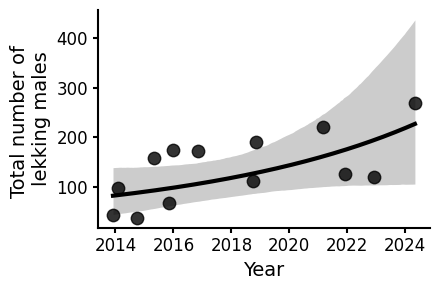

In [12]:
fig, ax = plt.subplots(figsize=(4.5, 3))

# Compute posterior mean number of territories
mu = fit['alpha'].reshape(-1,1) + fit['beta'].reshape(-1,1) * t_grid[None,:]
y = np.exp(mu)
y_mean = np.mean(y, axis=0)
y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

# Plot model fits
ax.plot(date_grid, y_mean, linewidth=3, color='black')
ax.fill_between(date_grid, y_lower, y_upper, color='black', alpha=0.2, linewidth=0)

# Add scatter to the plot
ax.scatter(df_desc['date'], df_desc['N'], s=80, color='black', edgecolor='black', alpha=0.8, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Total number of \nlekking males', fontsize=14)

plt.tight_layout()
plt.savefig(out_dir/'demography.png', dpi=300, bbox_inches='tight')

In [13]:
## 2) Difference in NDVI through time
nnd_mod = """
data {
  int<lower=1> n_points;
  
  vector[n_points] t;
  vector[n_points] dndvi;
}

parameters {
  real alpha;
  real beta;

  real<lower=0> sigma;
}

model {
  alpha ~ normal(0, 1);
  beta ~ normal(0, 1);

  sigma ~ exponential(1);

  for (n in 1:n_points) {
    dndvi[n] ~ normal(alpha + beta * t[n], sigma);
  }
}
"""

In [14]:
nnd_data = {
    'n_points': len(df_desc),
    't': df_desc['t_centred'].astype(float).to_numpy(),
    'dndvi': df_desc['dNDVI'].astype(float).to_numpy()
}

posterior = stan.build(nnd_mod, data=nnd_data)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 1.1e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.11 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.12 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.1 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 9e-06 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.09 seconds.
  Adjust your expectations accordingly!


<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:23: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1755035/950189130.py:23: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta$NDVI', fontsize=14)


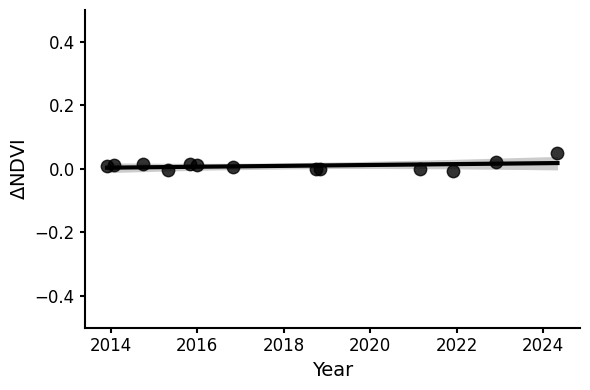

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

# Compute posterior mean number of territories
y = fit['alpha'].reshape(-1,1) + fit['beta'].reshape(-1,1) * t_grid[None,:]
y_mean = np.mean(y, axis=0)
y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

# Plot model fits
ax.plot(date_grid, y_mean, linewidth=3, color='black')
ax.fill_between(date_grid, y_lower, y_upper, color='black', alpha=0.2, linewidth=0)

# Add scatter to the plot
ax.scatter(df_desc['date'], df_desc['dNDVI'], s=80, color='black', edgecolor='black', alpha=0.8, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_ylim(-0.5,0.5)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('$\Delta$NDVI', fontsize=14)

plt.tight_layout()
# plt.savefig(out_dir/'ndvi.png', dpi=300, bbox_inches='tight')

In [16]:
## Month look-up chart
month_lookup = {'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6, 
                'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12}

## Parse date from file label
def parse_yyMMM(label):
    '''
    Convert labels like '13DEC' or '14FEB' into a pandas Timestamp
    '''
    m = re.match(r'^(\d{2})([A-Z]{3})$', label.upper())
    if m is None:
        raise ValueError(f'Unrecognized date label: {label}')
        
    yy = int(m.group(1))
    mon = month_lookup[m.group(2)]
    return pd.Timestamp(datetime(2000 + yy, mon, 1))

def read_lek_csv(date_dir, date_label, lek_num):
    '''
    Read csv without raising an error if csv was not found
    '''
    f = date_dir / f'{date_label}_LEK{lek_num}.csv'
    if not f.exists():
        return None
    
    df = pd.read_csv(f)
    
    return df[['latitude', 'longitude']].copy()

In [17]:
# Discover date folders
base_dir = Path('rawdata/Velavadar')
data_dirs = sorted([p for p in base_dir.glob('*_COORDINATES') if p.is_dir()])

# Collect per-date point sets
date_records = []
for d in data_dirs:
    date_label = d.name.replace('_COORDINATES', '').upper()
    date_ts = parse_yyMMM(date_label)

    df1 = read_lek_csv(d, date_label, 1)
    df2 = read_lek_csv(d, date_label, 2)

    date_records.append({'date_label': date_label, 'date': date_ts, 'lek1': df1, 'lek2': df2})

date_records = sorted(date_records, key=lambda r: r['date'])

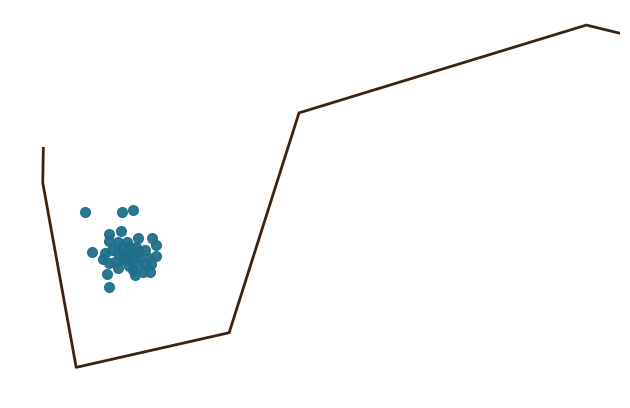

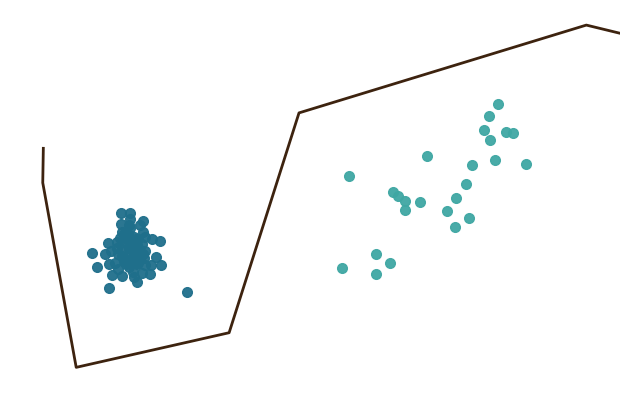

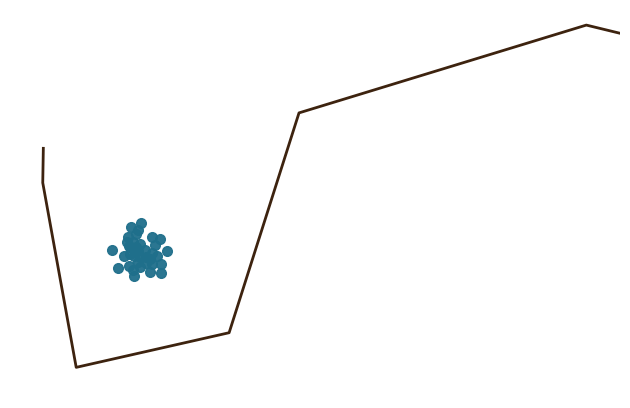

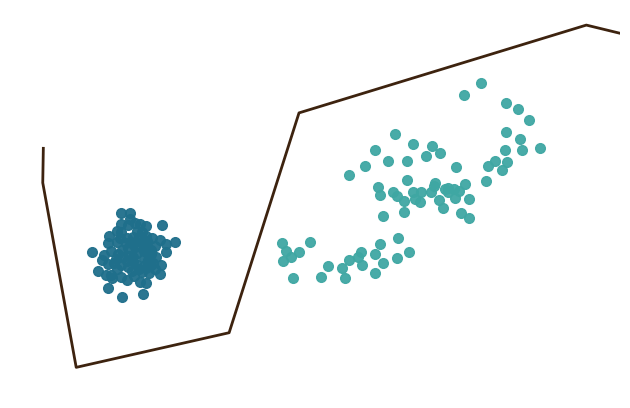

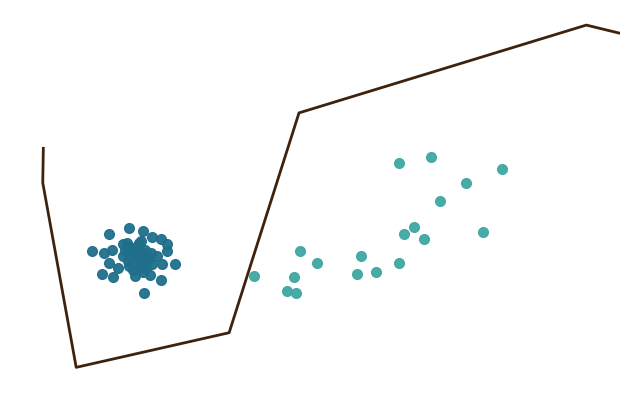

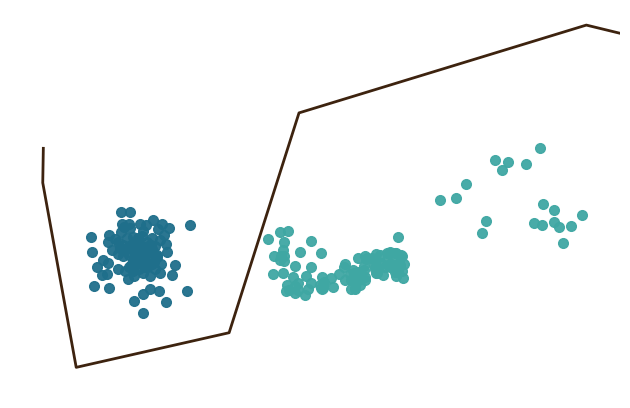

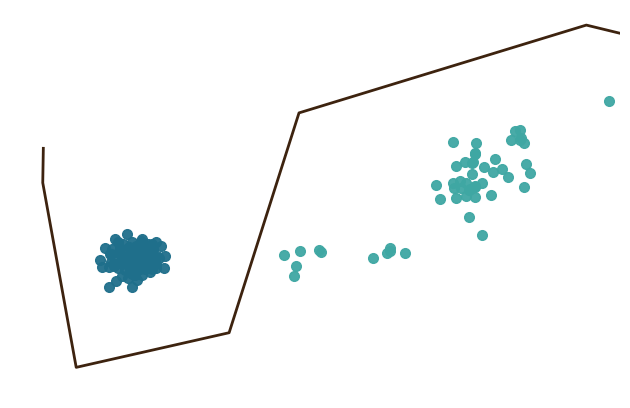

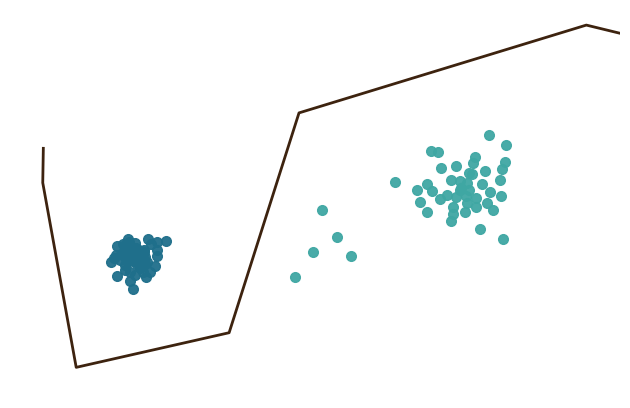

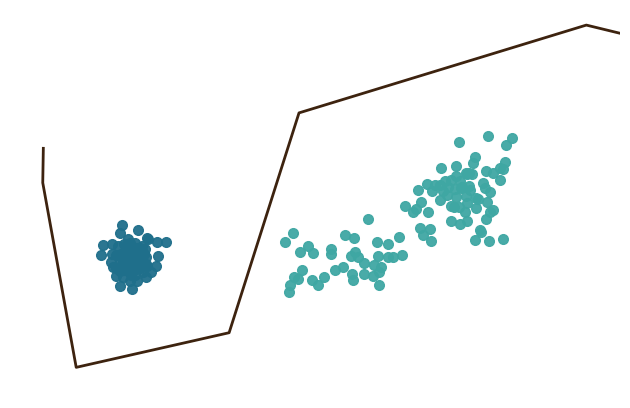

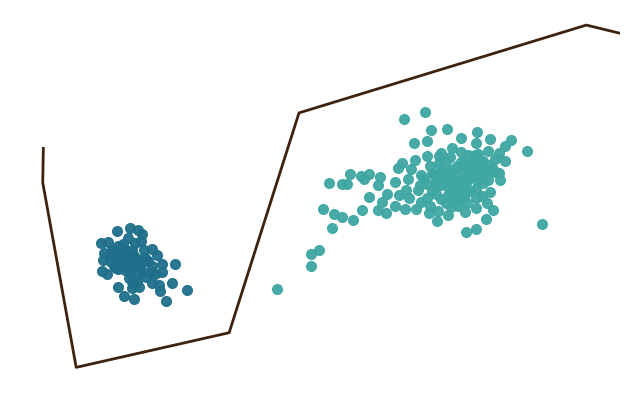

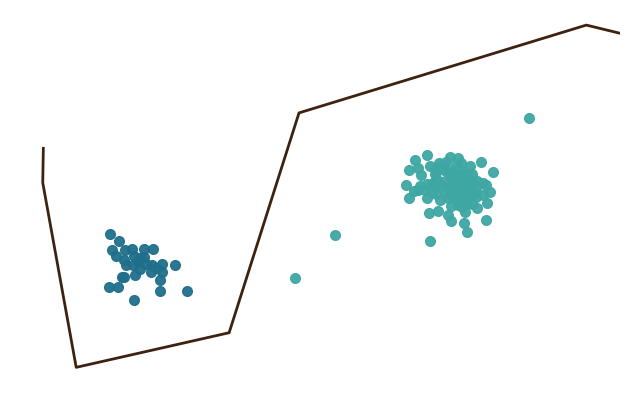

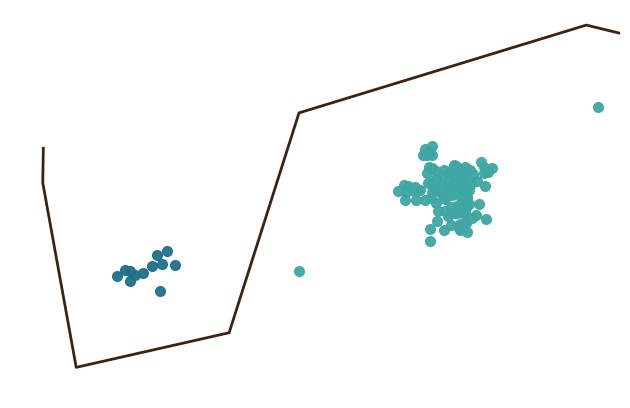

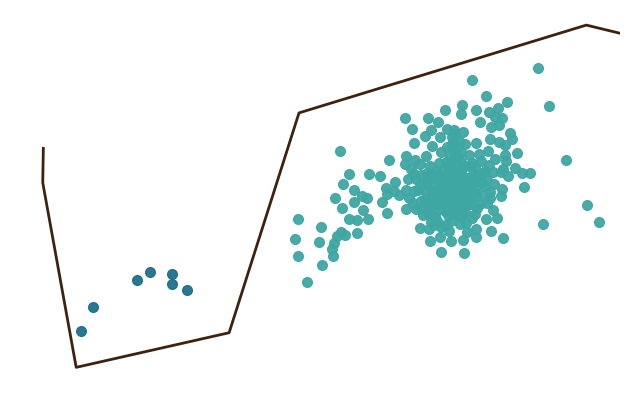

In [18]:
## Load roads and plot one figure per date
roads_gdf = gpd.read_file('rawdata/Velavadar/VelavadarRoads.shp', engine='pyogrio')

## Plot figure
for rec in date_records:
    fig, ax = plt.subplots(1,1)

    roads_gdf.plot(ax=ax, linewidth=2, color='#3D230F', zorder=1)

    if rec['lek1'] is not None:
        ax.scatter(rec['lek1']['longitude'], rec['lek1']['latitude'], s=50, 
                   facecolor=fill_cols.get('Velavadar Lek 1'), edgecolor=fill_cols.get('Velavadar Lek 1'),
                   linewidth=0.9, alpha=0.95, zorder=3, label='Lek 1')

    if rec['lek2'] is not None:
        ax.scatter(rec['lek2']['longitude'], rec['lek2']['latitude'], s=50, 
                   facecolor=fill_cols.get('Velavadar Lek 2'), edgecolor=fill_cols.get('Velavadar Lek 2'),
                   linewidth=0.9, alpha=0.95, zorder=4, label='Lek 2')

    ax.set_xlim(72.018,72.04) 
    ax.set_ylim(22.043,22.056)
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)

    fig.tight_layout()
    fig.savefig(out_dir/f"territories_{rec['date_label']}.png", dpi=300)
    plt.show()

### Model the total effect of social learning alone on the lek site transition

In [19]:
preference_mod = """
data {
  int<lower=2> n_points;
  array[n_points] int<lower=0> y;
  array[n_points] int<lower=1> N;
}

transformed data {
  vector[n_points] p_obs;
  vector[n_points] p_clip;

  for (n in 1:n_points) {
    p_obs[n] = (y[n] + 0.0) / N[n];
    p_clip[n] = fmin(fmax(p_obs[n], 1e-6), 1 - 1e-6);
  }
}

parameters {
  real<lower=0> beta;
}

transformed parameters {
  vector[n_points] mu;

  mu[1] = p_clip[1];

  for (n in 2:n_points) {
    mu[n] = inv_logit(beta * logit(p_clip[n-1]));
  }
}

model {
  beta ~ lognormal(0, 0.5);

  for (n in 2:n_points) {
    y[n] ~ binomial(N[n], mu[n]);
  }
}

generated quantities {
  array[n_points] int y_rep;
  vector[n_points] p_rep;

  y_rep[1] = y[1];
  p_rep[1] = p_obs[1];

  for (n in 2:n_points) {
    y_rep[n] = binomial_rng(N[n], mu[n]);
    p_rep[n] = (y_rep[n] + 0.0) / N[n];
  }
}
"""

In [20]:
dNDVI = df['dNDVI'].astype(float).to_numpy()
logN1 = df['logN1'].astype(float).to_numpy()
dNDVI_z = (dNDVI - dNDVI.mean()) / dNDVI.std(ddof=0)
logN1_z = (logN1 - logN1.mean()) / logN1.std(ddof=0)

data_transition = {
    'n_points': len(df),
    'y': df['N2'].astype(int).values,
    'N': df['N'].astype(int).values
}

posterior = stan.build(preference_mod, data=data_transition)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 1.7e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.17 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.7e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.17 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.12 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.1e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.11 seconds.
  Adjust your expectations accordingly!


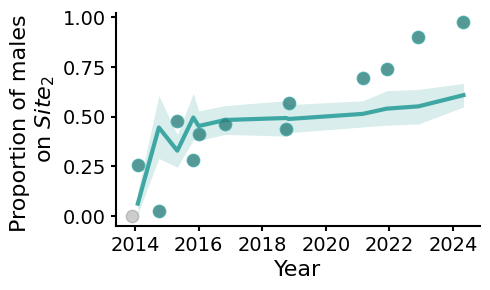

In [21]:
## Plot the transition of males from site 1 to site 2
fig, ax = plt.subplots(figsize=(5, 3))

## Summarise the posterior predictive replicate data
p_rep_mean = np.mean(fit['p_rep'], axis=1)
p_rep_lower,p_rep_upper = np.quantile(fit['p_rep'], [0.025,0.975], axis=1)

## Plot posterior predictive mean and interval
ax.plot(df['date'][1:], fit['p_rep'].mean(axis=1)[1:], linewidth=3, color=fill_cols.get('Velavadar Lek 2'), label=str('Velavadar Lek 2'))
ax.fill_between(df['date'][1:], p_rep_lower[1:], p_rep_upper[1:], color=fill_cols.get('Velavadar Lek 2'), alpha=0.2, linewidth=0)

## Add observed data as scatter
ax.scatter(df['date'][1:], df['p2'][1:], s=80, color=point_cols.get('Velavadar Lek 2'), edgecolor=fill_cols.get('Velavadar Lek 2'), alpha=0.8, zorder=4)
ax.scatter(df['date'][0], df['p2'][0], s=80, color='grey', edgecolor='grey', alpha=0.4, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=14, width=1.5)

ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Proportion of males \non $Site_{2}$', fontsize=16)

plt.tight_layout()
# plt.savefig(out_dir/'transition_mod_copying.png', dpi=300)

### Model the total effect of asocial innovation and social learning on the lek site transition
#### Here, asocial innovation is modelled as being symmetric. That individuals are equally likely to innovate to $Site_1$ as $Site_2$

In [22]:
preference_mod = """
data {
  int<lower=2> n_points;
  array[n_points] int<lower=0> y;
  array[n_points] int<lower=1> N;
}

transformed data {
  vector[n_points] p_obs;
  vector[n_points] p_clip;

  for (n in 1:n_points) {
    p_obs[n] = (y[n] + 0.0) / N[n];
    p_clip[n] = fmin(fmax(p_obs[n], 1e-6), 1 - 1e-6);
  }
}

parameters {
  real<lower=0> beta;
  real<lower=0, upper=1> eps;
}

transformed parameters {
  vector[n_points] mu;

  mu[1] = p_clip[1];

  for (n in 2:n_points) {
    real copy = inv_logit(beta * logit(p_clip[n-1]));
    real innov = 0.5;

    mu[n] = (1 - eps) * copy + eps * innov;
  }
}

model {
  beta ~ lognormal(0, 0.5);
  eps ~ beta(2, 2);

  for (n in 2:n_points) {
    y[n] ~ binomial(N[n], mu[n]);
  }
}

generated quantities {
  array[n_points] int y_rep;
  vector[n_points] p_rep;

  y_rep[1] = y[1];
  p_rep[1] = p_obs[1];

  for (n in 2:n_points) {
    y_rep[n] = binomial_rng(N[n], mu[n]);
    p_rep[n] = (y_rep[n] + 0.0) / N[n];
  }
}
"""

In [23]:
dNDVI = df['dNDVI'].astype(float).to_numpy()
logN1 = df['logN1'].astype(float).to_numpy()
dNDVI_z = (dNDVI - dNDVI.mean()) / dNDVI.std(ddof=0)
logN1_z = (logN1 - logN1.mean()) / logN1.std(ddof=0)

data_transition = {
    'n_points': len(df),
    'y': df['N2'].astype(int).values,
    'N': df['N'].astype(int).values
}

posterior = stan.build(preference_mod, data=data_transition)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 1.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.16 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.4e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.14 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.12 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.4e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.14 seconds.
  Adjust your expectations accordingly!


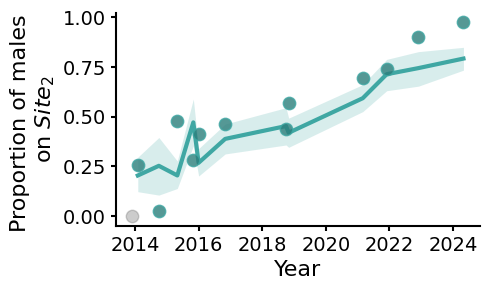

In [24]:
## Plot the transition of males from site 1 to site 2
fig, ax = plt.subplots(figsize=(5, 3))

## Summarise the posterior predictive replicate data
p_rep_mean = np.mean(fit['p_rep'], axis=1)
p_rep_lower,p_rep_upper = np.quantile(fit['p_rep'], [0.025,0.975], axis=1)

## Plot posterior predictive mean and interval
ax.plot(df['date'][1:], fit['p_rep'].mean(axis=1)[1:], linewidth=3, color=fill_cols.get('Velavadar Lek 2'), label=str('Velavadar Lek 2'))
ax.fill_between(df['date'][1:], p_rep_lower[1:], p_rep_upper[1:], color=fill_cols.get('Velavadar Lek 2'), alpha=0.2, linewidth=0)

## Add observed data as scatter
ax.scatter(df['date'][1:], df['p2'][1:], s=80, color=point_cols.get('Velavadar Lek 2'), edgecolor=fill_cols.get('Velavadar Lek 2'), alpha=0.8, zorder=4)
ax.scatter(df['date'][0], df['p2'][0], s=80, color='grey', edgecolor='grey', alpha=0.4, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=14, width=1.5)

ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Proportion of males \non $Site_{2}$', fontsize=16)

plt.tight_layout()
# plt.savefig(out_dir/'transition_mod_copying.png', dpi=300)

### Model the total effect of extrinsically-driven innovation on the lek site transition

In [25]:
preference_mod = """
data {
  int<lower=2> n_points;
  array[n_points] int<lower=0> y;
  array[n_points] int<lower=1> N;

  vector[n_points] dNDVI_z;
  vector[n_points] logN_z;
}

transformed data {
  vector[n_points] p_obs;
  vector[n_points] p_clip;

  for (n in 1:n_points) {
    p_obs[n] = (y[n] + 0.0) / N[n];
    p_clip[n] = fmin(fmax(p_obs[n], 1e-6), 1 - 1e-6);
  }
}

parameters {
  real gamma_NDVI;
  real delta_N;
}

transformed parameters {
  vector[n_points] mu;

  mu[1] = p_clip[1];

  for (n in 2:n_points) {
    mu[n] = inv_logit(gamma_NDVI * dNDVI_z[n-1] + delta_N * logN_z[n-1]);
  }
}

model {
  gamma_NDVI ~ normal(0, 1);
  delta_N ~ normal(0, 1);

  for (n in 2:n_points) {
    y[n] ~ binomial(N[n], mu[n]);
  }
}

generated quantities {
  array[n_points] int y_rep;
  vector[n_points] p_rep;

  y_rep[1] = y[1];
  p_rep[1] = p_obs[1];

  for (n in 2:n_points) {
    y_rep[n] = binomial_rng(N[n], mu[n]);
    p_rep[n] = (y_rep[n] + 0.0) / N[n];
  }
}
"""

In [26]:
dNDVI = df['dNDVI'].astype(float).to_numpy()
logN = np.log(df['N']).astype(float).to_numpy()
dNDVI_z = (dNDVI - dNDVI.mean()) / dNDVI.std(ddof=0)
logN_z = (logN - logN.mean()) / logN.std(ddof=0)

data_transition = {
    'n_points': len(df),
    'y': df['N2'].astype(int).values,
    'N': df['N'].astype(int).values,
    'logN_z': logN_z.astype(float),
    'dNDVI_z': dNDVI_z.astype(float)
}

posterior = stan.build(preference_mod, data=data_transition)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 1.9e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.19 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.3e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.13 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.3e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.13 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 1.1e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.11 seconds.
  Adjust your expectations accordingly!


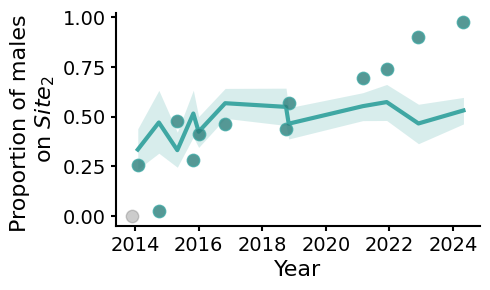

In [27]:
## Plot the transition of males from site 1 to site 2
fig, ax = plt.subplots(figsize=(5, 3))

## Summarise the posterior predictive replicate data
p_rep_mean = np.mean(fit['p_rep'], axis=1)
p_rep_lower,p_rep_upper = np.quantile(fit['p_rep'], [0.025,0.975], axis=1)

## Plot posterior predictive mean and interval
ax.plot(df['date'][1:], fit['p_rep'].mean(axis=1)[1:], linewidth=3, color=fill_cols.get('Velavadar Lek 2'), label=str('Velavadar Lek 2'))
ax.fill_between(df['date'][1:], p_rep_lower[1:], p_rep_upper[1:], color=fill_cols.get('Velavadar Lek 2'), alpha=0.2, linewidth=0)

## Add observed data as scatter
ax.scatter(df['date'][1:], df['p2'][1:], s=80, color=point_cols.get('Velavadar Lek 2'), edgecolor=fill_cols.get('Velavadar Lek 2'), alpha=0.8, zorder=4)
ax.scatter(df['date'][0], df['p2'][0], s=80, color='grey', edgecolor='grey', alpha=0.4, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=14, width=1.5)

ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Proportion of males \non $Site_{2}$', fontsize=16)

plt.tight_layout()
plt.savefig(out_dir/'transition_mod_innovation.png', dpi=300)

### Model the total effect of extrinsically-driven innovation and intrinsic social learning on the lek site transition

In [28]:
preference_mod = """
data {
  int<lower=2> n_points;
  array[n_points] int<lower=0> y;
  array[n_points] int<lower=1> N;

  vector[n_points] dNDVI_z;
  vector[n_points] logN_z;
}

transformed data {
  vector[n_points] p_obs;
  vector[n_points] p_clip;

  for (n in 1:n_points) {
    p_obs[n] = (y[n] + 0.0) / N[n];
    p_clip[n] = fmin(fmax(p_obs[n], 1e-6), 1 - 1e-6);
  }
}

parameters {
  real<lower=0> beta;
  real<lower=0, upper=1> eps;

  real gamma_NDVI;
  real delta_N;
}

transformed parameters {
  vector[n_points] mu;

  mu[1] = p_clip[1];

  for (n in 2:n_points) {
    real copy  = inv_logit(beta * logit(p_clip[n-1]));
    real innov = inv_logit(gamma_NDVI * dNDVI_z[n-1] + delta_N * logN_z[n-1]);

    mu[n] = (1 - eps) * copy + eps * innov;
  }
}

model {
  beta ~ lognormal(0, 0.5);
  eps ~ beta(2, 2);

  gamma_NDVI ~ normal(0, 1);
  delta_N ~ normal(0, 1);

  for (n in 2:n_points) {
    y[n] ~ binomial(N[n], mu[n]);
  }
}

generated quantities {
  array[n_points] int y_rep;
  vector[n_points] p_rep;

  y_rep[1] = y[1];
  p_rep[1] = p_obs[1];

  for (n in 2:n_points) {
    y_rep[n] = binomial_rng(N[n], mu[n]);
    p_rep[n] = (y_rep[n] + 0.0) / N[n];
  }
}
"""

In [29]:
dNDVI = df['dNDVI'].astype(float).to_numpy()
logN = np.log(df['N']).astype(float).to_numpy()
dNDVI_z = (dNDVI - dNDVI.mean()) / dNDVI.std(ddof=0)
logN_z = (logN - logN.mean()) / logN.std(ddof=0)

data_transition = {
    'n_points': len(df),
    'y': df['N2'].astype(int).values,
    'N': df['N'].astype(int).values,
    'logN_z': logN_z.astype(float),
    'dNDVI_z': dNDVI_z.astype(float)
}

posterior = stan.build(preference_mod, data=data_transition)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:  25% (2000/8000)
Sampling:  50% (4000/8000)
Sampling:  75% (6000/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 2.8e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.28 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.8e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.28 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.9e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.29 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 2.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.22 seconds.
  Adjust your expectations accordingly!


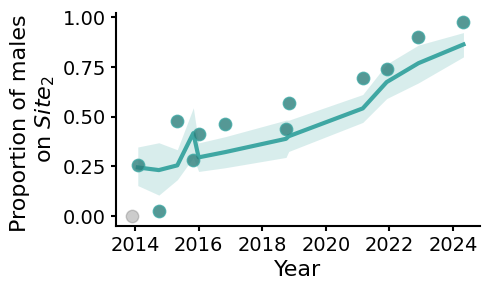

In [30]:
## Plot the transition of males from site 1 to site 2
fig, ax = plt.subplots(figsize=(5, 3))

## Summarise the posterior predictive replicate data
p_rep_mean = np.mean(fit['p_rep'], axis=1)
p_rep_lower,p_rep_upper = np.quantile(fit['p_rep'], [0.025,0.975], axis=1)

## Plot posterior predictive mean and interval
ax.plot(df['date'][1:], fit['p_rep'].mean(axis=1)[1:], linewidth=3, color=fill_cols.get('Velavadar Lek 2'), label=str('Velavadar Lek 2'))
ax.fill_between(df['date'][1:], p_rep_lower[1:], p_rep_upper[1:], color=fill_cols.get('Velavadar Lek 2'), alpha=0.2, linewidth=0)

## Add observed data as scatter
ax.scatter(df['date'][1:], df['p2'][1:], s=80, color=point_cols.get('Velavadar Lek 2'), edgecolor=fill_cols.get('Velavadar Lek 2'), alpha=0.8, zorder=4)
ax.scatter(df['date'][0], df['p2'][0], s=80, color='grey', edgecolor='grey', alpha=0.4, zorder=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=14, width=1.5)

ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Proportion of males \non $Site_{2}$', fontsize=16)

plt.tight_layout()
plt.savefig(out_dir/'transition_mod_copying.png', dpi=300)

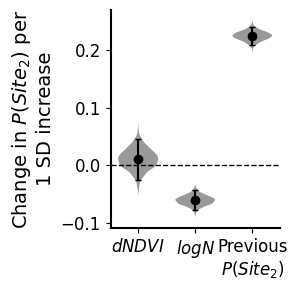

In [31]:
fig, ax = plt.subplots(figsize=(3, 3))

## Compute posterior effect distributions for the three transition predictors
innov_NDVI_lower = scipy.special.expit(fit['gamma_NDVI'].reshape(-1,1) * (dNDVI_z[:-1] - 0.5) + fit['delta_N'].reshape(-1,1) * logN_z[:-1])
innov_NDVI_upper = scipy.special.expit(fit['gamma_NDVI'].reshape(-1,1) * (dNDVI_z[:-1] + 0.5) + fit['delta_N'].reshape(-1,1) * logN_z[:-1])
innov_logN_lower = scipy.special.expit(fit['gamma_NDVI'].reshape(-1,1) * dNDVI_z[:-1] + fit['delta_N'].reshape(-1,1) * (logN_z[:-1] - 0.5))
innov_logN_upper = scipy.special.expit(fit['gamma_NDVI'].reshape(-1,1) * dNDVI_z[:-1] + fit['delta_N'].reshape(-1,1) * (logN_z[:-1] + 0.5))

p_NDVI = np.mean(fit['eps'].reshape(-1,1) * (innov_NDVI_upper - innov_NDVI_lower), axis=1)
p_logN = np.mean(fit['eps'].reshape(-1,1) * (innov_logN_upper - innov_logN_lower), axis=1)

## Copying effect is for a 1 SD change in previous occupancy of Site 2
p_prev = df['p2'].values[:-1]
p_prev_sd = np.std(p_prev, ddof=0)

p_prev_lower = np.clip(p_prev - 0.5 * p_prev_sd, 1e-6, 1 - 1e-6)
p_prev_upper = np.clip(p_prev + 0.5 * p_prev_sd, 1e-6, 1 - 1e-6)

copy_lower = scipy.special.expit(fit['beta'].reshape(-1,1) * scipy.special.logit(p_prev_lower))
copy_upper = scipy.special.expit(fit['beta'].reshape(-1,1) * scipy.special.logit(p_prev_upper))

p_copy = np.mean((1 - fit['eps'].reshape(-1,1)) * (copy_upper - copy_lower), axis=1)

## Violin plot
effects = [p_NDVI, p_logN, p_copy]
positions = [1, 2, 3]

parts = ax.violinplot(effects, positions=positions, widths=0.7, showmeans=False, showmedians=False, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('black')
    pc.set_edgecolor('none')
    pc.set_alpha(0.4)

## Compute medians + 95% intervals
medians = [np.median(p_NDVI), np.median(p_logN), np.median(p_copy)]
lowers = [np.quantile(p_NDVI, 0.025), np.quantile(p_logN, 0.025), np.quantile(p_copy, 0.025)]
uppers = [np.quantile(p_NDVI, 0.975), np.quantile(p_logN, 0.975), np.quantile(p_copy, 0.975)]

## Overlay median + intervals
for x, med, low, up in zip(positions, medians, lowers, uppers):
    ax.errorbar(x, med, yerr=[[med-low], [up-med]], fmt='o', color='black', markersize=6, capsize=2, zorder=3)

ax.axhline(0, linestyle='--', color='black', linewidth=1)

ax.set_xticks(positions)
ax.set_xticklabels(['$dNDVI$', '$logN$', 'Previous\n$P(Site_2)$'], fontsize=14)

ax.set_ylabel('Change in $P(Site_2)$ per \n1 SD increase', fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig(out_dir/'transition_causal_effects.png', dpi=300, bbox_inches='tight')

In [32]:
medians, lowers, uppers

([np.float64(0.010679271395959046),
  np.float64(-0.060504089354590215),
  np.float64(0.22453903301743727)],
 [np.float64(-0.025985699189257257),
  np.float64(-0.07727749205021604),
  np.float64(0.20775929192802026)],
 [np.float64(0.046394246088616024),
  np.float64(-0.043332781128579315),
  np.float64(0.2403461317512284)])

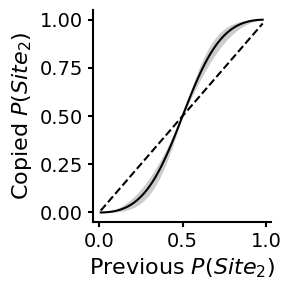

In [33]:
x = np.arange(0.01, 0.99, 0.01)
y = scipy.special.expit(fit['beta'].reshape(-1,1) * scipy.special.logit(x))
y_mean = np.mean(y, axis=0)
y_lower, y_upper = np.quantile(y, [0.025, 0.975], axis=0)

fig, ax = plt.subplots(1,1, figsize=(3,3))

ax.plot(x, y_mean, c='black', linewidth=1.5)
ax.fill_between(x, y_lower, y_upper, color='black', alpha=0.2, linewidth=0)
ax.plot(x, x, c='black', linestyle='dashed')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=14, width=1.5)

ax.set_xlabel('Previous $P(Site_2)$', fontsize=16)
ax.set_ylabel('Copied $P(Site_2)$', fontsize=16)

plt.tight_layout()
plt.savefig(out_dir/'transition_copying_map.png', dpi=300, bbox_inches='tight')

In [34]:
np.median(fit['beta']), np.quantile(fit['beta'], 0.025), np.quantile(fit['beta'], 0.975)

(np.float64(2.214076588882522),
 np.float64(1.8124219517119533),
 np.float64(2.713795946892557))